# MobileNetV2 con ImageNet, clasificación binaria y fine-tuning para sonrisa/no sonrisa

Este notebook mantiene **MobileNetV2 con pesos de ImageNet** para dos usos:

1. Clasificación directa con las **1000 clases originales de ImageNet**.
2. Extracción de características con MobileNetV2.
3. Clasificación binaria **sonrisa / no sonrisa** usando MobileNetV2 como extractor de características, seguido de:
   - `GlobalAveragePooling2D`
   - `Dense(1, activation="sigmoid")`
4. Fine-tuning del modelo binario:
   - Se entrena primero la cabeza binaria con MobileNetV2 congelado.
   - Después se descongelan las **últimas 30 capas** de MobileNetV2.
   - Se recompila con `learning_rate=1e-5`.
   - Se entrena por **15 épocas** adicionales.

Para usar MobileNetV2 correctamente, las imágenes pasan por `preprocess_input`, la base se carga con `weights="imagenet"` e `include_top=False` para clasificación binaria, y durante fine-tuning se mantiene `training=False` al llamar al modelo base para evitar actualizar indebidamente las capas BatchNorm.


## 1) Configuración de rutas y parámetros


In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

# Montar Google Drive
drive.mount("/content/drive")

# Ruta de la carpeta en Google Drive
BASE_DIR = "/content/drive/MyDrive/dataset_smile"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Verificar que las carpetas sí existen
for path in [BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, "->", os.path.exists(path))

# MobileNetV2 con include_top=True usa entrada 224x224x3
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE


Mounted at /content/drive
/content/drive/MyDrive/dataset_smile -> True
/content/drive/MyDrive/dataset_smile/train -> True
/content/drive/MyDrive/dataset_smile/val -> True
/content/drive/MyDrive/dataset_smile/test -> True


## 2) Cargar MobileNetV2 original de ImageNet


In [2]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Modelo original con:
# - pesos de ImageNet
# - capa superior incluida
# - 1000 clases originales
mobilenetv2 = MobileNetV2(
    weights="imagenet",
    include_top=True,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

mobilenetv2.trainable = False

mobilenetv2.summary()


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,538,984 (13.50 MB)

## 3) Usar MobileNetV2 como extractor de características

Se toma la salida de la penúltima capa del mismo modelo ImageNet. Esto conserva el modelo original y no agrega una cabeza nueva de clasificación.


In [3]:
# Salida previa a la capa final 'predictions'.
# En MobileNetV2 corresponde al vector de características antes de clasificar.
feature_extractor = tf.keras.Model(
    inputs=mobilenetv2.input,
    outputs=mobilenetv2.layers[-2].output,
    name="mobilenetv2_feature_extractor"
)

feature_extractor.trainable = False

print("Salida del extractor:", feature_extractor.output_shape)


Salida del extractor: (None, 1280)


## 4) Clasificación directa de una imagen con clases originales de ImageNet


Top 5 predicciones ImageNet:
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
pajama: 0.1711
lab_coat: 0.1266
apron: 0.0733
candle: 0.0712
kimono: 0.0248


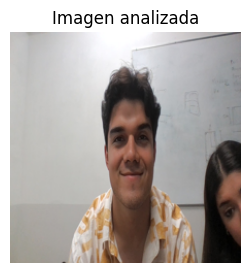

In [4]:
# Cambia esta ruta por la imagen que quieras analizar
img_path = "/content/drive/MyDrive/WIN_20260427_19_57_40_Pro.jpg"

img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
x = np.asarray(img).astype("float32")
x = np.expand_dims(x, axis=0)
x_pre = preprocess_input(x.copy())

preds = mobilenetv2.predict(x_pre, verbose=0)

print("Top 5 predicciones ImageNet:")
for imagenet_id, label, prob in decode_predictions(preds, top=5)[0]:
    print(f"{label}: {prob:.4f}")

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen analizada")
plt.show()


## 5) Extraer características de una sola imagen


In [5]:
features = feature_extractor.predict(x_pre, verbose=0)

print("Shape del vector de características:", features.shape)
print("Primeros 10 valores:")
print(features[0][:10])


Shape del vector de características: (1, 1280)
Primeros 10 valores:
[8.5934334e-02 2.3167896e-01 1.2180179e-01 7.5131083e-01 1.2432808e+00
 2.3639771e-01 1.7018077e+00 1.0225140e-03 4.7951832e-02 7.9425031e-01]


## 6) Crear datasets desde carpetas sin modificar clases del modelo

Las carpetas se usan únicamente para cargar imágenes y extraer vectores de características. No se entrena ni se cambia MobileNetV2.


In [6]:
def make_image_dataset(directory, shuffle=False):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        shuffle=shuffle
    )

train_ds = make_image_dataset(TRAIN_DIR, shuffle=False)
val_ds   = make_image_dataset(VAL_DIR, shuffle=False)
test_ds  = make_image_dataset(TEST_DIR, shuffle=False)

# Estas clases son solo las etiquetas de tus carpetas.
# No sustituyen las 1000 clases originales de ImageNet.
folder_class_names = train_ds.class_names
print("Clases de carpetas:", folder_class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Clases de carpetas: ['0_no_smile', '1_smile']


## 7) Extraer características de todo el dataset


In [7]:
def extract_features(ds):
    all_features = []
    all_labels = []

    for images, labels in ds:
        images_pre = preprocess_input(tf.cast(images, tf.float32))
        batch_features = feature_extractor.predict(images_pre, verbose=0)
        all_features.append(batch_features)
        all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels

X_train_features, y_train = extract_features(train_ds)
X_val_features, y_val     = extract_features(val_ds)
X_test_features, y_test   = extract_features(test_ds)

print("X_train_features:", X_train_features.shape)
print("X_val_features:", X_val_features.shape)
print("X_test_features:", X_test_features.shape)


X_train_features: (1400, 1280)
X_val_features: (300, 1280)
X_test_features: (300, 1280)


## 8) Guardar características extraídas


In [8]:
OUT_DIR = "/content/drive/MyDrive/mobilenetv2_features"
os.makedirs(OUT_DIR, exist_ok=True)

np.save(os.path.join(OUT_DIR, "X_train_features.npy"), X_train_features)
np.save(os.path.join(OUT_DIR, "y_train.npy"), y_train)

np.save(os.path.join(OUT_DIR, "X_val_features.npy"), X_val_features)
np.save(os.path.join(OUT_DIR, "y_val.npy"), y_val)

np.save(os.path.join(OUT_DIR, "X_test_features.npy"), X_test_features)
np.save(os.path.join(OUT_DIR, "y_test.npy"), y_test)

print("Características guardadas en:", OUT_DIR)


Características guardadas en: /content/drive/MyDrive/mobilenetv2_features


## 9) MobileNetV2 como extractor para sonrisa / no sonrisa

En esta sección se usa MobileNetV2 con `weights="imagenet"` y `include_top=False` para remover la cabeza original de 1000 clases.

Después se agrega una cabeza pequeña para clasificación binaria:

- `GlobalAveragePooling2D`: convierte los mapas de características en un vector compacto.
- `Dense(1, activation="sigmoid")`: entrega una probabilidad entre 0 y 1.

La salida cercana a 0 corresponde a la clase con índice `0`; la salida cercana a 1 corresponde a la clase con índice `1`.

Se usa la API funcional para llamar explícitamente a la base como `base_model_smile(x, training=False)`. Esto es importante cuando se hace fine-tuning con MobileNetV2, porque mantiene las capas BatchNorm en modo inferencia y evita cambios inestables en sus estadísticas internas.


In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# MobileNetV2 sin la cabeza original de ImageNet.
# Esta configuración permite usar la red como extractor de características visuales.
base_model_smile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Etapa 1: MobileNetV2 congelado.
# Solo se entrena la cabeza binaria al inicio.
base_model_smile.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
x = layers.Lambda(preprocess_input, name="mobilenetv2_preprocess")(inputs)

# training=False mantiene BatchNorm en modo inferencia.
# Esto es recomendado al usar modelos preentrenados para transferencia/fine-tuning.
x = base_model_smile(x, training=False)

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
outputs = layers.Dense(1, activation="sigmoid", name="smile_sigmoid_output")(x)

smile_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="mobilenetv2_smile_binary_classifier"
)

smile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

smile_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_smile_binary_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ smile_sigmoid_output (Dense)    │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10) Cargar datasets para clasificación binaria

El modelo espera que el dataset tenga dos carpetas dentro de `train`, `val` y `test`.

Ejemplo:

```text
dataset_smile/
├── train/
│   ├── no_smile/
│   └── smile/
├── val/
│   ├── no_smile/
│   └── smile/
└── test/
    ├── no_smile/
    └── smile/
```

TensorFlow asigna los índices de clase en orden alfabético. Por eso se imprime el mapeo antes de entrenar.

In [10]:
def make_binary_dataset(directory, shuffle=True):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        label_mode="binary",
        shuffle=shuffle
    )

train_binary_ds = make_binary_dataset(TRAIN_DIR, shuffle=True)
val_binary_ds   = make_binary_dataset(VAL_DIR, shuffle=False)
test_binary_ds  = make_binary_dataset(TEST_DIR, shuffle=False)

class_names = train_binary_ds.class_names
print("Mapeo de clases:")
print(f"0 -> {class_names[0]}")
print(f"1 -> {class_names[1]}")

train_binary_ds = train_binary_ds.prefetch(AUTOTUNE)
val_binary_ds   = val_binary_ds.prefetch(AUTOTUNE)
test_binary_ds  = test_binary_ds.prefetch(AUTOTUNE)

Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Mapeo de clases:
0 -> 0_no_smile
1 -> 1_smile


## 11) Entrenamiento inicial de la cabeza binaria

En esta etapa solo se entrena la capa densa sigmoide agregada al final. MobileNetV2 permanece congelado y actúa como extractor de características.

Después de esta etapa se realizará fine-tuning descongelando únicamente las últimas 30 capas de MobileNetV2.


In [11]:
INITIAL_EPOCHS = 10

history = smile_model.fit(
    train_binary_ds,
    validation_data=val_binary_ds,
    epochs=INITIAL_EPOCHS
)


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 356ms/step - accuracy: 0.5064 - loss: 0.7251 - val_accuracy: 0.5333 - val_loss: 0.7105
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.5307 - loss: 0.7021 - val_accuracy: 0.5400 - val_loss: 0.6893
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.5507 - loss: 0.6853 - val_accuracy: 0.5800 - val_loss: 0.6726
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.5857 - loss: 0.6698 - val_accuracy: 0.6067 - val_loss: 0.6577
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.6050 - loss: 0.6569 - val_accuracy: 0.6233 - val_loss: 0.6461
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.6300 - loss: 0.6465 - val_accuracy: 0.6433 - val_loss: 0.6351
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.6500 - loss: 0.6354 - val_accuracy: 0.6600 - val_loss: 0.6259
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.6579 - loss: 0.6262 - val_accuracy: 0.6633

## 12) Fine-tuning: descongelar las últimas 30 capas

Ahora se realiza el fine-tuning solicitado:

- Se activa `base_model_smile.trainable = True`.
- Se congelan todas las capas excepto las últimas `30`.
- Se mantienen congeladas las capas `BatchNormalization` para estabilidad.
- Se recompila el modelo con `learning_rate=1e-5`.
- Se entrena por `15` épocas adicionales.


In [12]:
FINE_TUNE_LAYERS = 30
FINE_TUNE_EPOCHS = 15

# Activar fine-tuning en MobileNetV2
base_model_smile.trainable = True

# Congelar todas las capas excepto las últimas 30
fine_tune_at = max(0, len(base_model_smile.layers) - FINE_TUNE_LAYERS)

for layer in base_model_smile.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model_smile.layers[fine_tune_at:]:
    layer.trainable = True

# Recomendado en fine-tuning de modelos preentrenados:
# mantener BatchNormalization congelado para no alterar estadísticas internas.
for layer in base_model_smile.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_base_layers = [
    layer.name for layer in base_model_smile.layers
    if layer.trainable
]

print("Total de capas en MobileNetV2:", len(base_model_smile.layers))
print("Índice desde donde inicia el fine-tuning:", fine_tune_at)
print("Capas entrenables de MobileNetV2 durante fine-tuning:", len(trainable_base_layers))
print("Últimas capas entrenables:")
for name in trainable_base_layers[-10:]:
    print(" -", name)

# Recompilar con learning rate bajo para fine-tuning
smile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = smile_model.fit(
    train_binary_ds,
    validation_data=val_binary_ds,
    epochs=FINE_TUNE_EPOCHS
)


Total de capas en MobileNetV2: 154
Índice desde donde inicia el fine-tuning: 124
Capas entrenables de MobileNetV2 durante fine-tuning: 19
Últimas capas entrenables:
 - block_15_depthwise_relu
 - block_15_project
 - block_15_add
 - block_16_expand
 - block_16_expand_relu
 - block_16_depthwise
 - block_16_depthwise_relu
 - block_16_project
 - Conv_1
 - out_relu
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 392ms/step - accuracy: 0.7043 - loss: 0.5731 - val_accuracy: 0.7533 - val_loss: 0.5041
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7857 - loss: 0.4628 - val_accuracy: 0.7900 - val_loss: 0.4744
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.8250 - loss: 0.4055 - val_accuracy: 0.7633 - val_loss: 0.4247
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.8543 - loss: 0.3586 - val_accuracy: 0.8067 - val_loss: 0.3961
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.8843 - loss: 0.3091 - val_accuracy: 0.8267 - val_loss: 0.3861
E

## 13) Gráficas de entrenamiento y fine-tuning

Estas gráficas muestran dos etapas:

1. Entrenamiento inicial de la cabeza binaria con MobileNetV2 congelado.
2. Fine-tuning con las últimas 30 capas de MobileNetV2 habilitadas y `learning_rate=1e-5`.


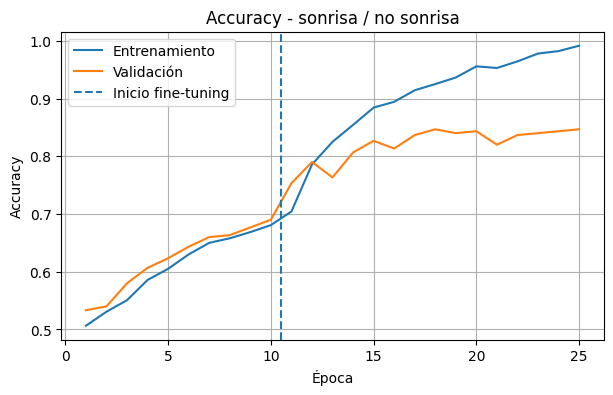

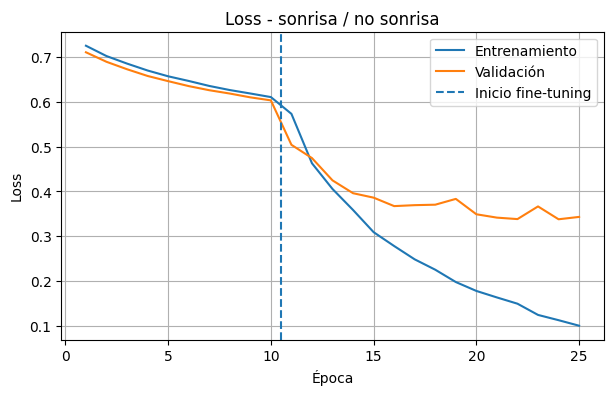

In [13]:
# Unir historial del entrenamiento inicial y del fine-tuning
acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]

loss = history.history["loss"] + fine_tune_history.history["loss"]
val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)
fine_tune_start = len(history.history["accuracy"])

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, acc, label="Entrenamiento")
plt.plot(epochs_range, val_acc, label="Validación")
plt.axvline(fine_tune_start + 0.5, linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy - sonrisa / no sonrisa")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validación")
plt.axvline(fine_tune_start + 0.5, linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss - sonrisa / no sonrisa")
plt.legend()
plt.grid(True)
plt.show()


## 14) Evaluación final en el conjunto de prueba

Se evalúa el desempeño del modelo después del fine-tuning.


In [14]:
test_loss, test_acc = smile_model.evaluate(test_binary_ds)

print(f"Test loss final: {test_loss:.4f}")
print(f"Test accuracy final: {test_acc:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7833 - loss: 0.4897
Test loss final: 0.4897
Test accuracy final: 0.7833


## 15) Predicción final: sonrisa o no sonrisa en una imagen

La salida del modelo es una probabilidad sigmoide.

- Si la probabilidad es menor que `0.5`, se asigna la clase `0`.
- Si la probabilidad es mayor o igual que `0.5`, se asigna la clase `1`.

Recuerda revisar el mapeo impreso previamente, porque TensorFlow asigna las clases en orden alfabético.


Probabilidad sigmoide: 0.0039
Clase predicha: 0_no_smile


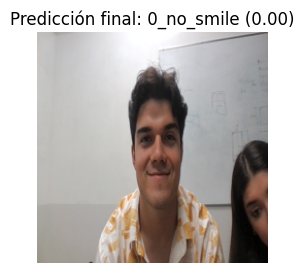

In [15]:
# Cambia esta ruta por una imagen propia.
img_path = "/content/drive/MyDrive/WIN_20260427_19_57_40_Pro.jpg"

img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
x = np.asarray(img).astype("float32")
x = np.expand_dims(x, axis=0)

prob = float(smile_model.predict(x, verbose=0)[0][0])
pred_index = int(prob >= 0.5)
pred_label = class_names[pred_index]

print(f"Probabilidad sigmoide: {prob:.4f}")
print(f"Clase predicha: {pred_label}")

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicción final: {pred_label} ({prob:.2f})")
plt.show()


## 16) Guardar el modelo binario con fine-tuning

Guarda el modelo completo después del fine-tuning para usarlo después sin volver a entrenar.


In [16]:
MODEL_OUT = "/content/drive/MyDrive/mobilenetv2_smile_finetuned.keras"
smile_model.save(MODEL_OUT)
print("Modelo con fine-tuning guardado en:", MODEL_OUT)


Modelo con fine-tuning guardado en: /content/drive/MyDrive/mobilenetv2_smile_finetuned.keras
